# 2-Sample t-test <hr style="border:2.5px solid rgb(28, 75, 147)"></hr>

<b>Sidney Louise G. Monillo</b>
<br>Computer Engineer/Technician

In [14]:
# import libraries
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.power import TTestIndPower

In [9]:
# loading dataset
df = pd.read_csv(r"datasets/social_media_engagement1.csv",
                 delimiter=",")

df.head()

,post_id,platform,post_type,post_time,likes,comments,shares,post_day,sentiment_score
0,1,Facebook,image,8/17/2023 14:45,2121,474,628,Thursday,positive
1,2,Facebook,carousel,5/14/2023 0:45,3660,432,694,Sunday,neutral
2,3,Instagram,poll,2/21/2023 16:15,4955,408,688,Tuesday,negative
3,4,Twitter,image,11/16/2023 0:45,1183,90,187,Thursday,negative
4,5,Twitter,video,5/23/2023 0:30,3499,247,286,Tuesday,positive


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   post_id          100 non-null    int64 
 1   platform         100 non-null    object
 2   post_type        100 non-null    object
 3   post_time        100 non-null    object
 4   likes            100 non-null    int64 
 5   comments         100 non-null    int64 
 6   shares           100 non-null    int64 
 7   post_day         100 non-null    object
 8   sentiment_score  100 non-null    object
dtypes: int64(4), object(5)
memory usage: 7.2+ KB


In [5]:
df.describe()

,post_id,likes,comments,shares
count,100.000000,100.000000,100.00000,100.000000
mean,50.500000,2381.810000,202.66000,415.650000
std,29.011492,1632.573284,138.84067,283.877601
min,1.000000,15.000000,10.00000,16.000000
25%,25.750000,895.750000,89.75000,183.000000
50%,50.500000,2220.000000,171.00000,356.500000
75%,75.250000,3593.250000,299.00000,689.500000
max,100.000000,5000.000000,500.00000,993.000000


In [6]:
# filtering instagram and facebook data
instagram = df[df["platform"] == "Instagram"]["likes"]
facebook = df[df["platform"] == "Facebook"]["likes"]

print("Instagram sample size:", len(instagram))
print("Facebook sample size:", len(facebook))

Instagram sample size: 36
Facebook sample size: 32


In [7]:
# summary statistics
print("Instagram Likes Summary")
print(instagram.describe())

print("\nFacebook Likes Summary")
print(facebook.describe())

Instagram Likes Summary
count      36.000000
mean     2999.833333
std      1726.949027
min        15.000000
25%      1490.500000
50%      3227.000000
75%      4668.250000
max      5000.000000
Name: likes, dtype: float64

Facebook Likes Summary
count      32.000000
mean     2699.750000
std      1579.812014
min        45.000000
25%      1693.000000
50%      2415.500000
75%      4028.250000
max      5000.000000
Name: likes, dtype: float64


C:\Users\sidne\AppData\Local\Temp\ipykernel_1264\3077525480.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([instagram, facebook], labels=["Instagram","Facebook"])


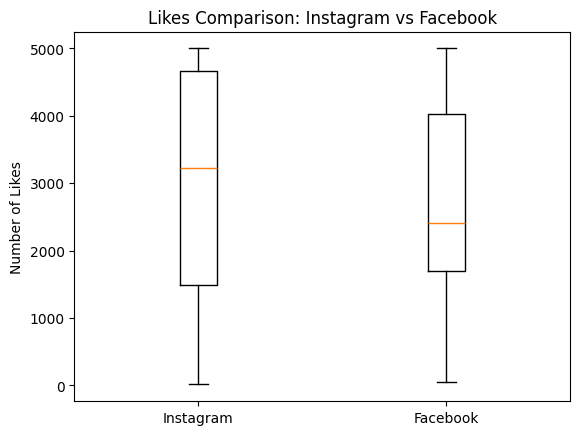

In [8]:
# boxplot
plt.boxplot([instagram, facebook], labels=["Instagram","Facebook"])

plt.title("Likes Comparison: Instagram vs Facebook")
plt.ylabel("Number of Likes")

plt.show()

In [10]:
# Normality Test
print("Instagram Normality Test")
stat, p = stats.shapiro(instagram)
print("p-value:", p)

print("\nFacebook Normality Test")
stat, p = stats.shapiro(facebook)
print("p-value:", p)

Instagram Normality Test
p-value: 0.0022766684458233977

Facebook Normality Test
p-value: 0.058056790752494654


In [11]:
# 2-Sample t-test
t_stat, p_value = stats.ttest_ind(instagram, facebook, equal_var=False)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 0.748253561073465
P-value: 0.4569678290015541


In [12]:
# hypothesis
alpha = 0.05

if p_value < alpha:
    print("Reject H0: There is a significant difference in likes between Instagram and Facebook.")
else:
    print("Fail to Reject H0: No significant difference in likes between Instagram and Facebook.")

Fail to Reject H0: No significant difference in likes between Instagram and Facebook.


In [15]:
# power of the test
# compute means
mean_instagram = instagram.mean()
mean_facebook = facebook.mean()

# compute standard deviations
std_instagram = instagram.std(ddof=1)
std_facebook = facebook.std(ddof=1)

# sample sizes
n1 = len(instagram)
n2 = len(facebook)

# pooled standard deviation
pooled_std = (((n1-1)*std_instagram**2 + (n2-1)*std_facebook**2) / (n1+n2-2))**0.5

# Cohen's d
effect_size = (mean_instagram - mean_facebook) / pooled_std

print("Cohen's d (Effect Size):", effect_size)

analysis = TTestIndPower()

power = analysis.power(
    effect_size=effect_size,
    nobs1=n1,
    ratio=n2/n1,
    alpha=0.05,
    alternative='two-sided'
)

print("Statistical Power:", power)

Cohen's d (Effect Size): 0.18083139757696162
Statistical Power: 0.11355003215266699
